In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [101]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]
len(words)

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [102]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 3), generator=g)
W1 = torch.randn((9, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [103]:
for p in parameters:
    p.requires_grad = True

In [104]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs


tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
# lri = []
# lossi = []
for i in range(10000):

    # minibatch construct
    ix = torch.randint(0, X.shape[0], (256,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 9) @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.15
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lr)
    # lossi.append(loss.item())




2.481675386428833
2.319336414337158
1.7906874418258667
2.494330883026123
2.326071262359619
2.568423271179199
2.095210552215576
2.1648643016815186
2.0152435302734375
2.287146806716919
2.2917885780334473
2.524435520172119
2.0373122692108154
2.3343708515167236
2.4586989879608154
2.2138655185699463
2.547698497772217
2.3250880241394043
2.4208638668060303
2.468698024749756
2.5868077278137207
1.9587314128875732
2.412118911743164
2.292243242263794
2.2314460277557373
2.197559118270874
2.151273250579834
2.295330047607422
2.7319576740264893
2.3801815509796143
2.101485013961792
2.4838078022003174
2.018981456756592
2.403130531311035
2.256782293319702
2.5803728103637695
2.6378376483917236
2.071955442428589
2.4663631916046143
2.5907280445098877
2.482123374938965
2.722748041152954
2.2346153259277344
2.5079386234283447
2.6699886322021484
2.3096671104431152
2.3736281394958496
2.56475567817688
2.4459259510040283
2.4358062744140625
1.9290305376052856
2.659989595413208
2.0662665367126465
2.674407482147217


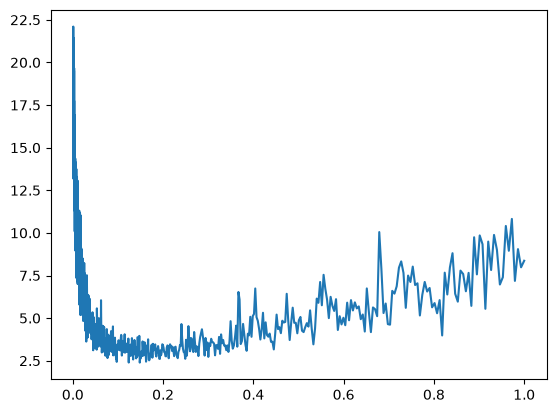

In [89]:
plt.plot(lri, lossi)

In [79]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.882401466369629
